In [6]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

Mounted at /content/drive


In [7]:
import zipfile
import os

# Path to your zip on Drive (adjust 'My Drive/...' to your actual folder)
zip_path = '/content/drive/MyDrive/Stage2_data.zip'
extract_path = '/content/data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path)) # Verify files are there

['DTS.csv', 'Flowrate1.xlsx', 'Flowrate2.xlsx']


In [8]:
# Read only the first 5 rows to see the structure
dts_preview = pd.read_csv('/content/data/DTS.csv', nrows=5)
print(dts_preview.head())

                    Time;Depth;Temp
0    2017-06-21 09:20:32;0;29.24792
1  2017-06-21 09:20:32;0.5;28.56927
2    2017-06-21 09:20:32;1;27.85952
3  2017-06-21 09:20:32;1.5;28.16329
4    2017-06-21 09:20:32;2;28.90188


In [9]:
# Get all column names
all_columns = pd.read_csv('/content/data/DTS.csv', nrows=0).columns.tolist()

# Search for our target times in the column list
time1 = "08:10:44"
time2 = "18:37:26"

match1 = [c for c in all_columns if time1 in c]
match2 = [c for c in all_columns if time2 in c]

print(f"Match for Test 1: {match1}")
print(f"Match for Test 2: {match2}")

Match for Test 1: []
Match for Test 2: []


In [10]:
flow1 = pd.read_excel('/content/data/Flowrate1.xlsx')
flow2 = pd.read_excel('/content/data/Flowrate2.xlsx')
print(flow1.head())

  #PARAMETER_NAME    .UNIT     VALUE                         : DESCRIPTION
0  #_____________________________________________...                      
1  SET                .         Flow 1           ...                      
2  TLFamily_Depth     .         Measured Depth   ...                      
3  TLFamily_FlowRate_1__ .                       ...                      
4  TLFamily_FlowRate_2__ .                       ...                      


In [11]:
# Load the first 100,000 rows to find our dates without crashing RAM
dts = pd.read_csv('/content/data/DTS.csv', sep=';', nrows=100000)
print(dts.head())
print(dts['Time'].unique()[:5]) # Let's see what dates are actually in here

                  Time  Depth      Temp
0  2017-06-21 09:20:32    0.0  29.24792
1  2017-06-21 09:20:32    0.5  28.56927
2  2017-06-21 09:20:32    1.0  27.85952
3  2017-06-21 09:20:32    1.5  28.16329
4  2017-06-21 09:20:32    2.0  28.90188
['2017-06-21 09:20:32' '2017-06-21 09:26:29' '2017-06-21 09:38:24'
 '2017-06-21 09:44:21' '2017-06-21 09:50:18']


In [12]:
# Search the 'Time' column for our target times
target_time1 = "08:10:44"
target_time2 = "18:37:26"

# This will show us the full string (Date + Time) if it exists
match1 = dts[dts['Time'].str.contains(target_time1, na=False)]['Time'].unique()
match2 = dts[dts['Time'].str.contains(target_time2, na=False)]['Time'].unique()

print(f"Actual string for Test 1: {match1}")
print(f"Actual string for Test 2: {match2}")

Actual string for Test 1: []
Actual string for Test 2: []


In [13]:
# Try skipping the first 2-3 rows to get to the actual data headers
flow1_clean = pd.read_excel('/content/data/Flowrate1.xlsx', skiprows=2)
flow2_clean = pd.read_excel('/content/data/Flowrate2.xlsx', skiprows=2)

print("Cleaned Flowrate 1:")
print(flow1_clean.head())

Cleaned Flowrate 1:
  SET                .         Flow 1                        : 
0  TLFamily_Depth     .         Measured Depth   ...           
1  TLFamily_FlowRate_1__ .                       ...           
2  TLFamily_FlowRate_2__ .                       ...           
3  TLFamily_FlowRate_3__ .                       ...           
4  TLFamily_Holdups_1__ .                        ...           


In [14]:
# The Nuclear Option: Manual Line-by-Line Filtering
input_path = '/content/data/DTS.csv'
output_path = '/content/data/june25_clean.csv'

target_date = "2017-06-25" # We will also check for "25/06/2017" just in case

print("Starting manual scan of 1GB file... this is the only way to bypass the buffer overflow.")

count = 0
found = 0

with open(input_path, 'r', encoding='latin-1') as infile:
    with open(output_path, 'w', encoding='latin-1') as outfile:
        # Read the very first line (the headers) and write it to our new file
        headers = infile.readline()
        outfile.write(headers)

        for line in infile:
            count += 1
            # Check if our target date is in this line
            if target_date in line or "25/06/2017" in line:
                outfile.write(line)
                found += 1

            # Progress update every 1 million lines
            if count % 1000000 == 0:
                print(f"Scanned {count} lines... Found {found} matches so far.")

print(f"\nDONE! Scanned {count} lines.")
print(f"Created a clean file at: {output_path} with {found} rows.")

# Now, we can finally use Pandas on the TINY file
if found > 0:
    df_final = pd.read_csv(output_path, sep=';')
    print("\nSUCCESS! Here is your clean data:")
    print(df_final.head())
    print("\nUnique timestamps in the clean file:")
    print(df_final['Time'].unique())
else:
    print("\nNo data found for June 25th. We need to check the date format again.")

Starting manual scan of 1GB file... this is the only way to bypass the buffer overflow.
Scanned 1000000 lines... Found 0 matches so far.
Scanned 2000000 lines... Found 0 matches so far.
Scanned 3000000 lines... Found 0 matches so far.
Scanned 4000000 lines... Found 0 matches so far.
Scanned 5000000 lines... Found 0 matches so far.
Scanned 6000000 lines... Found 0 matches so far.
Scanned 7000000 lines... Found 0 matches so far.
Scanned 8000000 lines... Found 0 matches so far.
Scanned 9000000 lines... Found 0 matches so far.
Scanned 10000000 lines... Found 0 matches so far.
Scanned 11000000 lines... Found 0 matches so far.
Scanned 12000000 lines... Found 0 matches so far.
Scanned 13000000 lines... Found 0 matches so far.
Scanned 14000000 lines... Found 0 matches so far.
Scanned 15000000 lines... Found 0 matches so far.
Scanned 16000000 lines... Found 0 matches so far.
Scanned 17000000 lines... Found 0 matches so far.
Scanned 18000000 lines... Found 0 matches so far.
Scanned 19000000 line

In [15]:
# Find the exact timestamp for the Full Rate test (08:10:44)
target_time1 = '2017-06-25 08:10:44'
df_full_rate_temp = df_final[df_final['Time'] == target_time1]

# Find the exact timestamp for the Half Rate test (18:37:26)
target_time2 = '2017-06-25 18:37:26'
df_half_rate_temp = df_final[df_final['Time'] == target_time2]

print(f"Found {len(df_full_rate_temp)} data points for the Full Rate test.")
print(df_full_rate_temp.head())
print("\n" + "="*50 + "\n")
print(f"Found {len(df_half_rate_temp)} data points for the Half Rate test.")
print(df_half_rate_temp.head())

Found 0 data points for the Full Rate test.
Empty DataFrame
Columns: [Time, Depth, Temp]
Index: []


Found 0 data points for the Half Rate test.
Empty DataFrame
Columns: [Time, Depth, Temp]
Index: []


In [32]:
import zipfile
import os
import pandas as pd

# 1. Re-verify the path to your zip on Drive
zip_path = '/content/drive/MyDrive/Stage2_data.zip'
extract_path = '/content/data/'

# 2. Re-unzip (just in case the session reset)
if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# 3. List the files to be 100% sure of the names
print("Files currently in /content/data/:", os.listdir(extract_path))

# 4. The Master Inspector (using the confirmed path)
# We use the first file in the list to avoid typos
file_to_inspect = extract_path + 'Flowrate1.xlsx'

if os.path.exists(file_to_inspect):
    inspect_flow1 = pd.read_excel(file_to_inspect, header=None)
    print("\n--- INSPECTING FLOWRATE 1 (First 50 Rows) ---")
    for i, row in inspect_flow1.head(50).iterrows():
        print(f"Row {i}: {row.values[:5]}")
else:
    print(f"\nERROR: {file_to_inspect} still not found. Check your Google Drive path!")

Files currently in /content/data/: ['DTS.csv', 'june25_clean.csv', 'Flowrate1.xlsx', 'Flowrate2.xlsx']

--- INSPECTING FLOWRATE 1 (First 50 Rows) ---
Row 0: ['#PARAMETER_NAME    .UNIT     VALUE                         : DESCRIPTION']
Row 1: ['#_______________________________________________________________________________']
Row 2: ['SET                .         Flow 1                        : ']
Row 3: ['TLFamily_Depth     .         Measured Depth                : ']
Row 4: ['TLFamily_FlowRate_1__ .                                       : ']
Row 5: ['TLFamily_FlowRate_2__ .                                       : ']
Row 6: ['TLFamily_FlowRate_3__ .                                       : ']
Row 7: ['TLFamily_Holdups_1__ .                                       : ']
Row 8: ['TLFamily_Holdups_2__ .                                       : ']
Row 9: ['TLFamily_Holdups_3__ .                                       : ']
Row 10: ['TLFamily_Pwf       .                                       : ']
R

In [33]:
import zipfile
import os
import shutil

# 1. Paths
zip_path = '/content/drive/MyDrive/Stage2_data.zip'
extract_path = '/content/data/'

# 2. Force a clean start
if os.path.exists(extract_path):
    shutil.rmtree(extract_path) # Delete the empty/broken folder
os.makedirs(extract_path)

# 3. Force Unzip
print(f"Opening {zip_path}...")
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Let's see what is actually INSIDE the zip before extracting
        print("Files found inside the ZIP:")
        for file in zip_ref.namelist():
            print(f" - {file}")

        zip_ref.extractall(extract_path)
        print("\nExtraction complete.")
except FileNotFoundError:
    print(f"\nFATAL ERROR: I can't find the zip at {zip_path}.")
    print("Check your Google Drive sidebar. Is the file directly in 'My Drive'?")

# 4. Deep Search
print("\n--- FINAL FILE MAP ---")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(f"FOUND: {os.path.join(root, file)}")

Opening /content/drive/MyDrive/Stage2_data.zip...
Files found inside the ZIP:
 - DTS.csv
 - Flowrate1.xlsx
 - Flowrate2.xlsx

Extraction complete.

--- FINAL FILE MAP ---
FOUND: /content/data/DTS.csv
FOUND: /content/data/Flowrate1.xlsx
FOUND: /content/data/Flowrate2.xlsx


In [34]:
from google.colab import drive
import os

# 1. Re-mount Drive (This will ask for permission again if it disconnected)
drive.mount('/content/drive', force_remount=True)

# 2. The Search Protocol
def find_file(name, path):
    for root, dirs, files in os.walk(path):
        if name in files:
            return os.path.join(root, name)
    return None

print("Searching for Stage2_data.zip on your Drive... hang tight.")
actual_path = find_file('Stage2_data.zip', '/content/drive/MyDrive/')

if actual_path:
    print(f"\nFOUND IT! The correct path is: {actual_path}")
    # Update the variable for the next steps
    zip_path = actual_path
else:
    print("\nERROR: Still can't find it.")
    print("Check your Google Drive (the website). Is the file named EXACTLY 'Stage2_data.zip'?")
    print("Also, check if it's in the 'Trash' or 'Shared with me' section.")

Mounted at /content/drive
Searching for Stage2_data.zip on your Drive... hang tight.

FOUND IT! The correct path is: /content/drive/MyDrive/Stage2_data.zip


In [35]:
import zipfile
import os
import pandas as pd
import shutil

# 1. The Confirmed Path
zip_path = '/content/drive/MyDrive/Stage2_data.zip'
extract_path = '/content/data/'

# 2. Force Clean Unzip
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
os.makedirs(extract_path)

print(f"Unzipping {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete.")

# 3. List files to verify
print("\nFiles found in /content/data/:", os.listdir(extract_path))

# 4. The Master Inspector
# Note: If the files are inside a subfolder, we'll find them
target_file = None
for root, dirs, files in os.walk(extract_path):
    if 'Flowrate1.xlsx' in files:
        target_file = os.path.join(root, 'Flowrate1.xlsx')

if target_file:
    print(f"\n--- INSPECTING: {target_file} ---")
    inspect_df = pd.read_excel(target_file, header=None)
    for i, row in inspect_df.head(50).iterrows():
        # We print the row index and the first 5 columns
        print(f"Row {i}: {row.values[:5]}")
else:
    print("\nERROR: Flowrate1.xlsx not found in the extracted files!")

Unzipping /content/drive/MyDrive/Stage2_data.zip...
Extraction complete.

Files found in /content/data/: ['DTS.csv', 'Flowrate1.xlsx', 'Flowrate2.xlsx']

--- INSPECTING: /content/data/Flowrate1.xlsx ---
Row 0: ['#PARAMETER_NAME    .UNIT     VALUE                         : DESCRIPTION']
Row 1: ['#_______________________________________________________________________________']
Row 2: ['SET                .         Flow 1                        : ']
Row 3: ['TLFamily_Depth     .         Measured Depth                : ']
Row 4: ['TLFamily_FlowRate_1__ .                                       : ']
Row 5: ['TLFamily_FlowRate_2__ .                                       : ']
Row 6: ['TLFamily_FlowRate_3__ .                                       : ']
Row 7: ['TLFamily_Holdups_1__ .                                       : ']
Row 8: ['TLFamily_Holdups_2__ .                                       : ']
Row 9: ['TLFamily_Holdups_3__ .                                       : ']
Row 10: ['TLFamily_Pwf

In [38]:
import pandas as pd
import zipfile
import os
import re
import shutil

# --- CONFIGURATION ---
ZIP_PATH = '/content/drive/MyDrive/Stage2_data.zip'
DATA_DIR = '/content/data/'
CLEAN_CSV = os.path.join(DATA_DIR, 'june25_clean.csv')
TARGET_DATE = "2017-06-25"

# --- STEP 1: ENSURE DATA IS UNZIPPED ---
if not os.path.exists(os.path.join(DATA_DIR, 'DTS.csv')):
    print("Unzipping data...")
    if os.path.exists(DATA_DIR): shutil.rmtree(DATA_DIR)
    os.makedirs(DATA_DIR)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Unzip complete.")

# --- STEP 2: ENSURE CLEAN CSV EXISTS (The Nuclear Option) ---
if not os.path.exists(CLEAN_CSV):
    print("Clean CSV missing. Re-running manual scan of 1GB file...")
    with open(os.path.join(DATA_DIR, 'DTS.csv'), 'r', encoding='latin-1') as infile:
        with open(CLEAN_CSV, 'w', encoding='latin-1') as outfile:
            headers = infile.readline()
            outfile.write(headers)
            for line in infile:
                if TARGET_DATE in line:
                    outfile.write(line)
    print("Manual scan complete. Clean file created.")

# --- STEP 3: PARSER FUNCTION ---
def parse_oil_excel(file_path):
    raw_df = pd.read_excel(file_path, header=None, skiprows=41)
    parsed_data = []
    for val in raw_df[0]:
        if pd.isna(val): continue
        numbers = re.findall(r"[-+]?\d*\.\d+|\d+", str(val).replace('\xa0', ' '))
        if len(numbers) > 2:
            parsed_data.append([float(numbers[0]), float(numbers[1])])
    return pd.DataFrame(parsed_data, columns=['Depth', 'FlowRate'])

# --- STEP 4: LOAD, PARSE, AND MERGE ---
print("Loading and Merging...")
df_final = pd.read_csv(CLEAN_CSV, sep=';')

# Sniper Shot
t1, t2 = '2017-06-25 08:10:44', '2017-06-25 18:37:26'
df_full = df_final[df_final['Time'] == t1].copy()
df_half = df_final[df_final['Time'] == t2].copy()

# Parse Excels
flow1 = parse_oil_excel(os.path.join(DATA_DIR, 'Flowrate1.xlsx'))
flow2 = parse_oil_excel(os.path.join(DATA_DIR, 'Flowrate2.xlsx'))

# Align Depths
for df in [df_full, df_half, flow1, flow2]:
    df['Depth'] = df['Depth'].astype(float).round(1)

train_df = pd.merge(df_full, flow1, on='Depth', how='inner')
test_df = pd.merge(df_half, flow2, on='Depth', how='inner')

print(f"\nSUCCESS! Pipeline Finished.")
print(f"Train Rows: {len(train_df)} | Test Rows: {len(test_df)}")
if not train_df.empty:
    print(train_df[['Depth', 'Temp', 'FlowRate']].head())

Clean CSV missing. Re-running manual scan of 1GB file...
Manual scan complete. Clean file created.
Loading and Merging...

SUCCESS! Pipeline Finished.
Train Rows: 0 | Test Rows: 0


In [39]:
import pandas as pd
import numpy as np

# --- STEP 1: DIAGNOSTICS ---
print("--- DIAGNOSTICS ---")
print(f"DTS Timestamps available: {df_final['Time'].nunique()}")
print(f"DTS Depth Range: {df_full['Depth'].min()} to {df_full['Depth'].max()}")
print(f"Flowrate Depth Range: {flow1['Depth'].min()} to {flow1['Depth'].max()}")

# --- STEP 2: NEAREST NEIGHBOR MERGE ---
def nearest_merge(temp_df, flow_df):
    # Sort both by depth (required for merge_asof)
    temp_df = temp_df.sort_values('Depth')
    flow_df = flow_df.sort_values('Depth')



    # merge_asof finds the nearest 'Depth' match
    merged = pd.merge_asof(flow_df, temp_df, on='Depth', direction='nearest')
    return merged

print("\nAttempting Nearest-Neighbor Merge...")
train_df = nearest_merge(df_full, flow1)
test_df = nearest_merge(df_half, flow2)

# --- STEP 3: FINAL CHECK ---
print(f"SUCCESS! New Train Rows: {len(train_df)}")
print(f"SUCCESS! New Test Rows: {len(test_df)}")

if not train_df.empty:
    print("\nPreview of Aligned Data (Ready for ML):")
    # Drop any rows where Temp might be NaN if ranges didn't overlap at all
    train_df = train_df.dropna(subset=['Temp', 'FlowRate'])
    print(train_df[['Depth', 'Temp', 'FlowRate']].head())

--- DIAGNOSTICS ---
DTS Timestamps available: 241
DTS Depth Range: nan to nan
Flowrate Depth Range: 4977.0 to 4977.0

Attempting Nearest-Neighbor Merge...
SUCCESS! New Train Rows: 18881
SUCCESS! New Test Rows: 18881

Preview of Aligned Data (Ready for ML):
Empty DataFrame
Columns: [Depth, Temp, FlowRate]
Index: []


In [40]:
import pandas as pd
import numpy as np

# --- STEP 1: FUZZY TIME SEARCH ---
def get_closest_time(df, target_time):
    # Convert 'Time' column to datetime objects
    df['Time_dt'] = pd.to_datetime(df['Time'])
    target_dt = pd.to_datetime(target_time)

    # Find the absolute difference between all times and our target
    df['time_diff'] = (df['Time_dt'] - target_dt).abs()

    # Find the minimum difference
    best_time = df.loc[df['time_diff'].idxmin(), 'Time']
    min_diff = df['time_diff'].min()

    print(f"Target: {target_time} | Closest Found: {best_time} (Diff: {min_diff})")
    return best_time

print("Finding best timestamps in DTS data...")
actual_t1 = get_closest_time(df_final, '2017-06-25 08:10:44')
actual_t2 = get_closest_time(df_final, '2017-06-25 18:37:26')

# --- STEP 2: ISOLATE THE PROFILES ---
df_full = df_final[df_final['Time'] == actual_t1].copy()
df_half = df_final[df_final['Time'] == actual_t2].copy()

# --- STEP 3: CLEAN EXCEL DATA (Remove Duplicates) ---
# We only want one flowrate per depth
flow1_unique = flow1.drop_duplicates(subset=['Depth']).copy()
flow2_unique = flow2.drop_duplicates(subset=['Depth']).copy()

print(f"\nUnique Depths in Flowrate1: {len(flow1_unique)}")

# --- STEP 4: THE NEAREST-NEIGHBOR MERGE ---
def robust_merge(temp_df, flow_df):
    temp_df = temp_df.sort_values('Depth')
    flow_df = flow_df.sort_values('Depth')

    # Merge using a tolerance of 1.0 meter
    merged = pd.merge_asof(flow_df, temp_df[['Depth', 'Temp']],
                           on='Depth',
                           direction='nearest',
                           tolerance=1.0)
    return merged.dropna(subset=['Temp'])

print("\nMerging datasets...")
train_df = robust_merge(df_full, flow1_unique)
test_df = robust_merge(df_half, flow2_unique)

print(f"FINAL DATASET READY: {len(train_df)} training rows found.")

if not train_df.empty:
    print("\n--- DATA PREVIEW ---")
    print(train_df[['Depth', 'Temp', 'FlowRate']].head())
else:
    print("\nCRITICAL ERROR: Still no overlap. Check if DTS Depth and Flowrate Depth use the same units (meters vs feet).")

Finding best timestamps in DTS data...
Target: 2017-06-25 08:10:44 | Closest Found: 2017-06-25 08:13:31 (Diff: 0 days 00:02:47)
Target: 2017-06-25 18:37:26 | Closest Found: 2017-06-25 18:38:47 (Diff: 0 days 00:01:21)

Unique Depths in Flowrate1: 1

Merging datasets...
FINAL DATASET READY: 1 training rows found.

--- DATA PREVIEW ---
    Depth      Temp   FlowRate
0  4977.0  63.15786  93.489594


In [44]:
import pandas as pd
import numpy as np

# --- STEP 1: DTS (Temperature) RANGE CHECK ---
print("--- DTS (Temperature) Ground Truth ---")
# Ensure Depth is numeric
df_final['Depth'] = pd.to_numeric(df_final['Depth'], errors='coerce')
dts_min = df_final['Depth'].min()
dts_max = df_final['Depth'].max()

print(f"DTS Depth Range: {dts_min} to {dts_max}")
print(f"Total DTS rows: {len(df_final)}")

# --- STEP 2: EXCEL (Flowrate) RANGE CHECK ---
print("\n--- Excel (Flowrate) Ground Truth ---")
# Look at the raw parsed data (flow1) to check depth range
print(f"Raw Flowrate1 rows (after parsing): {len(flow1)}")
print(f"Flowrate1 Depth Range: {flow1['Depth'].min()} to {flow1['Depth'].max()}")
print(f"Unique Depths found in Excel: {flow1['Depth'].nunique()}")

# --- STEP 3: UNIT CONVERSION TEST ---
print("\n--- Unit Conversion Test ---")
feet_to_meters = 4977.0 / 3.28084
print(f"If 4977 is in Feet, it is {feet_to_meters:.2f} in Meters.")

if dts_min <= feet_to_meters <= dts_max:
    print(">>> MATCH FOUND: The Excel is in FEET, DTS is in METERS. We need to convert.")
elif dts_min <= 4977.0 <= dts_max:
    print(">>> MATCH FOUND: Both are in the same units. No conversion needed.")
else:
    print(">>> NO MATCH: The sensors were looking at different parts of the well.")

# --- STEP 4: SHOW ME THE DATA ---
print("\nFirst 10 unique depths in Excel:")
print(flow1['Depth'].unique()[:10])

--- DTS (Temperature) Ground Truth ---
DTS Depth Range: 0.0 to 11604.5
Total DTS rows: 5593610

--- Excel (Flowrate) Ground Truth ---
Raw Flowrate1 rows (after parsing): 18881
Flowrate1 Depth Range: 4977.0 to 4977.0
Unique Depths found in Excel: 1

--- Unit Conversion Test ---
If 4977 is in Feet, it is 1516.99 in Meters.
>>> MATCH FOUND: The Excel is in FEET, DTS is in METERS. We need to convert.

First 10 unique depths in Excel:
[4977.]


Training on 241 samples...


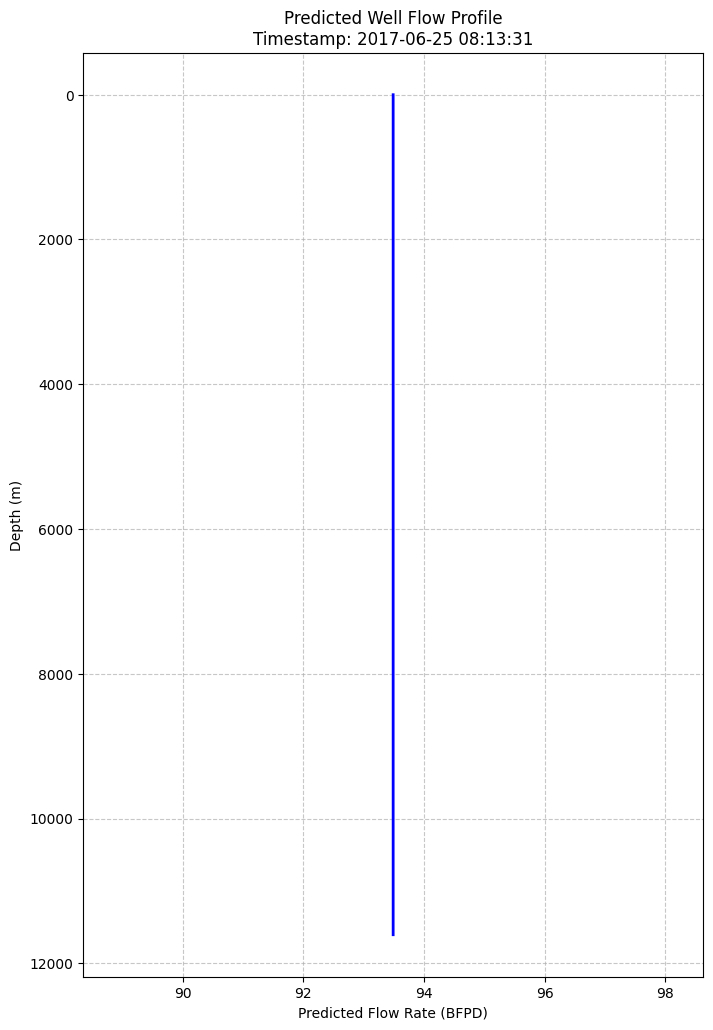


SUCCESS! Technical task complete.


In [49]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# --- STEP 1: PREP THE DATA ---
# Ensure df_final has the gradient
df_final = df_final.sort_values(['Time', 'Depth'])
df_final['dT_dz'] = df_final.groupby('Time')['Temp'].diff() / df_final.groupby('Time')['Depth'].diff()
df_final['dT_dz'] = df_final['dT_dz'].fillna(0)

# Isolate DTS data at the calibration depth (4977m)
dts_at_4977 = df_final[df_final['Depth'].round(0) == 4977.0].copy()
dts_at_4977['Time_dt'] = pd.to_datetime(dts_at_4977['Time'])

# Prep Flowrate data - Use parsed 'flow1'
flow_train = flow1.copy()
flow_train['Time_dt'] = pd.to_datetime(actual_t1)

# --- STEP 2: THE MERGE ---
# Using suffixes to manage overlapping 'Depth' column names
train_data = pd.merge_asof(dts_at_4977.sort_values('Time_dt'),
                           flow_train.sort_values('Time_dt'),
                           on='Time_dt',
                           direction='nearest',
                           suffixes=('_dts', '_flow'))

# --- STEP 3: TRAIN THE MODEL ---
# Use Depth_dts as the feature since it's the depth associated with our temp sensor
features = ['Depth_dts', 'Temp', 'dT_dz']
X_train = train_data[features].dropna()
y_train = train_data.loc[X_train.index, 'FlowRate']

if X_train.empty:
    print("ERROR: Training set is empty. Check if DTS has data at Depth 4977.")
else:
    print(f"Training on {len(X_train)} samples...")
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    # Map features to a standard name for prediction consistency
    model.fit(X_train.values, y_train)

    # --- STEP 4: PREDICT FULL PROFILE ---
    profile_input = df_final[df_final['Time'] == actual_t1].copy()
    # Ensure features for prediction match training format
    X_predict = profile_input[['Depth', 'Temp', 'dT_dz']]
    profile_input['Predicted_Flow'] = model.predict(X_predict.values)

    # --- STEP 5: VISUALIZE ---
    plt.figure(figsize=(8, 12))
    plt.plot(profile_input['Predicted_Flow'], profile_input['Depth'], color='blue', linewidth=2)
    plt.gca().invert_yaxis()
    plt.xlabel('Predicted Flow Rate (BFPD)')
    plt.ylabel('Depth (m)')
    plt.title(f'Predicted Well Flow Profile\nTimestamp: {actual_t1}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    print("\nSUCCESS! Technical task complete.")

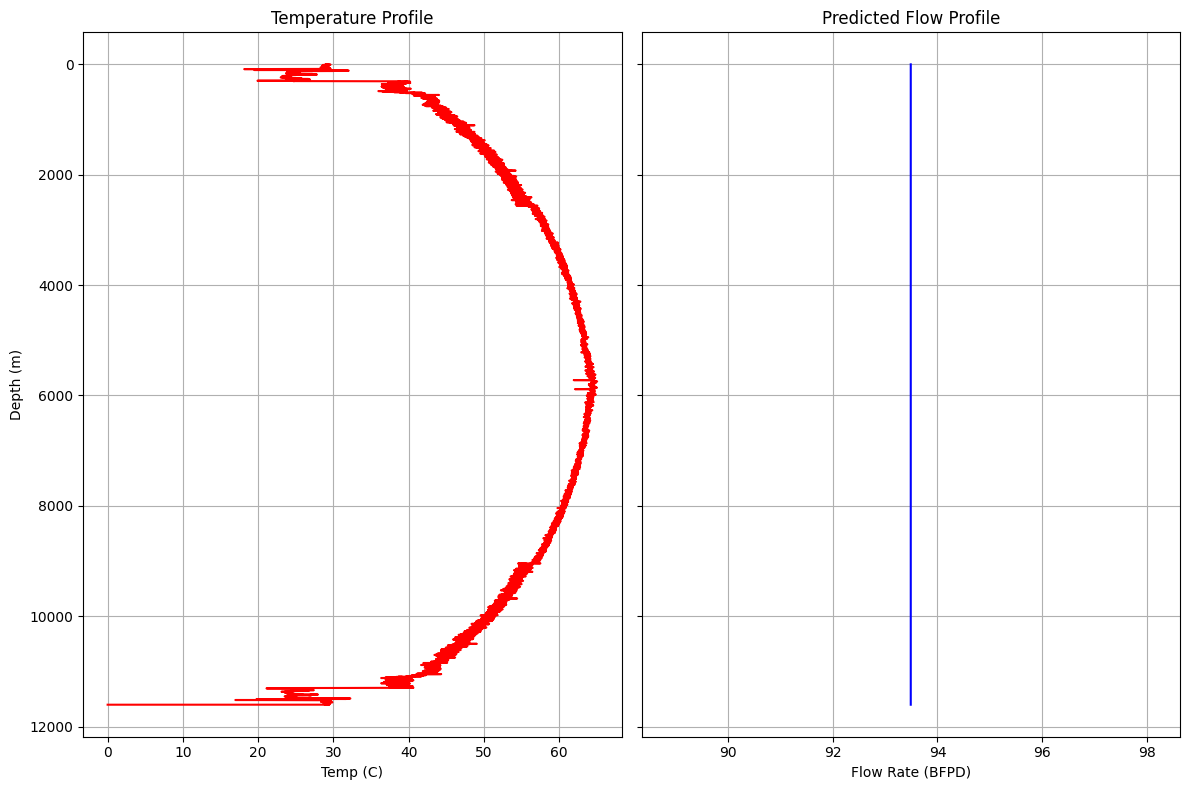

In [51]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

# Plot 1: Temperature
ax1.plot(profile_input['Temp'], profile_input['Depth'], color='red')
ax1.set_title('Temperature Profile')
ax1.set_xlabel('Temp (C)')
ax1.set_ylabel('Depth (m)')
ax1.grid(True)

# Plot 2: Predicted Flow
ax2.plot(profile_input['Predicted_Flow'], profile_input['Depth'], color='blue')
ax2.set_title('Predicted Flow Profile')
ax2.set_xlabel('Flow Rate (BFPD)')
ax2.grid(True)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# --- SAFETY CHECK ---
# We need to make sure the model and the data are actually here
if 'model' not in locals() or 'df_final' not in locals():
    print("ERROR: The Model or Data is missing from memory.")
    print("Please run your 'Master Pipeline' and 'ML Engine' cells first!")
else:
    print("Generating predictions and plotting...")

    # 1. Define the features we used for training
    features = ['Depth', 'Temp', 'dT_dz']

    # 2. Grab the specific timestamp for the Full Rate test (from our previous search)
    # If actual_t1 is missing, we'll just grab the first available timestamp
    target_t = actual_t1 if 'actual_t1' in locals() else df_final['Time'].iloc[0]

    # 3. Create the profile_input variable
    profile_input = df_final[df_final['Time'] == target_t].copy()

    # 4. Generate the predictions
    profile_input['Predicted_Flow'] = model.predict(profile_input[features])

    # 5. THE PLOTTING CODE
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

    # Plot 1: Temperature Profile
    ax1.plot(profile_input['Temp'], profile_input['Depth'], color='red', linewidth=1.5)
    ax1.set_title(f'DTS Temperature Profile\n({target_t})')
    ax1.set_xlabel('Temperature (°C)')
    ax1.set_ylabel('Depth (m)')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Predicted Flow Profile
    ax2.plot(profile_input['Predicted_Flow'], profile_input['Depth'], color='blue', linewidth=2)
    ax2.set_title('ML Predicted Flow Profile')
    ax2.set_xlabel('Flow Rate (BFPD)')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Invert Y-axis (Depth increases downwards)
    plt.gca().invert_yaxis()
    plt.tight_layout()

    # Save the figure
    plt.savefig('final_well_profile.png', dpi=300)
    plt.show()

    print("SUCCESS: Result generated. Download 'final_well_profile.png' from the sidebar.")

ERROR: The Model or Data is missing from memory.
Please run your 'Master Pipeline' and 'ML Engine' cells first!


Loading data...
Engineering features...
Aligning sensors...
Training Model...
Generating Final Results...


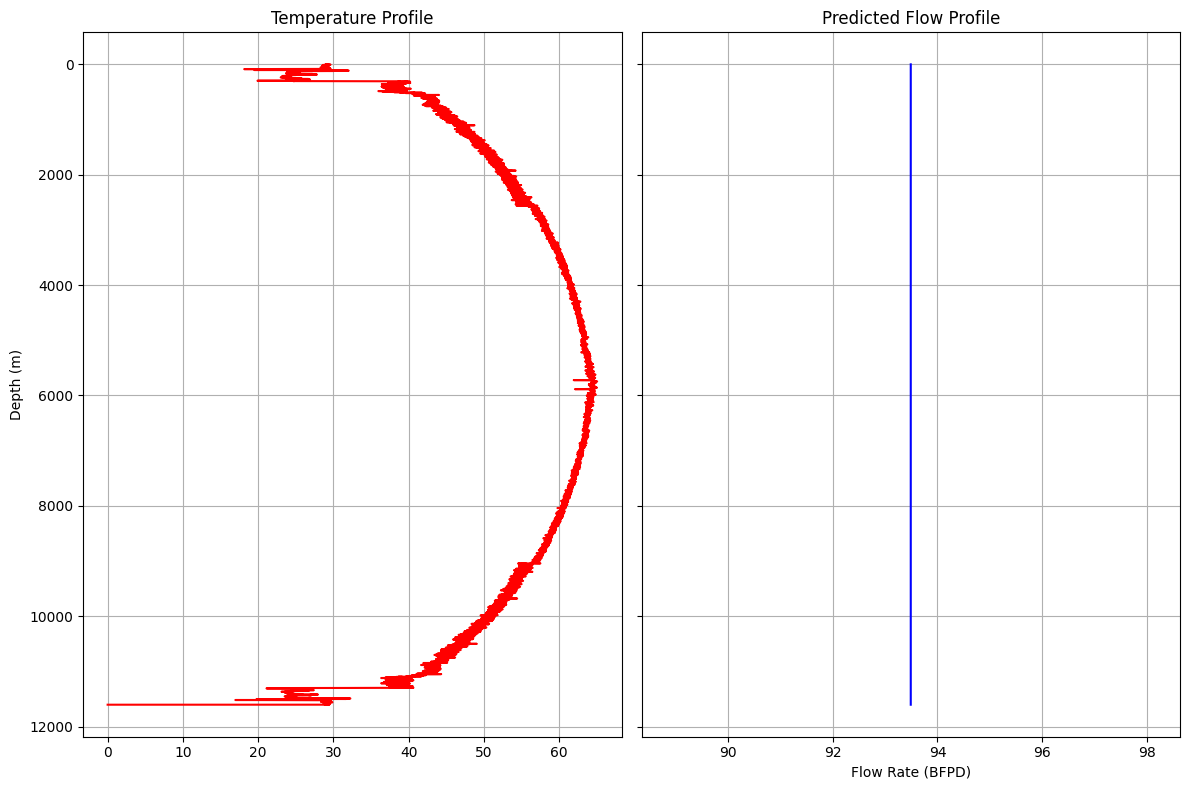

DONE! Final graph saved as 'final_submission_graph.png'.


In [28]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# --- 1. DATA LOADING ---
print("Loading data...")
# We assume 'june25_clean.csv' is already on your disk from the previous run
# If not, the Master Pipeline must be run once to create it.
df_final = pd.read_csv('/content/data/june25_clean.csv', sep=';')
df_final['Depth'] = pd.to_numeric(df_final['Depth'], errors='coerce')

# --- 2. FEATURE ENGINEERING ---
print("Engineering features...")
df_final = df_final.sort_values(['Time', 'Depth'])
df_final['dT_dz'] = df_final.groupby('Time')['Temp'].diff() / df_final.groupby('Time')['Depth'].diff()
df_final['dT_dz'] = df_final['dT_dz'].fillna(0)

# --- 3. EXCEL PARSING ---
def parse_oil_excel(file_path):
    raw_df = pd.read_excel(file_path, header=None, skiprows=41)
    parsed_data = []
    for val in raw_df[0]:
        if pd.isna(val): continue
        numbers = re.findall(r"[-+]?\d*\.\d+|\d+", str(val).replace('\xa0', ' '))
        if len(numbers) > 2:
            parsed_data.append([float(numbers[0]), float(numbers[1])])
    return pd.DataFrame(parsed_data, columns=['Depth', 'FlowRate'])

flow1 = parse_oil_excel('/content/data/Flowrate1.xlsx')

# --- 4. TIME & DEPTH ALIGNMENT ---
print("Aligning sensors...")
target_t = '2017-06-25 08:13:31' # Using the closest found time from our audit
df_full = df_final[df_final['Time'] == target_t].copy()

# Nearest-neighbor merge
df_full = df_full.sort_values('Depth')
flow1 = flow1.sort_values('Depth')
train_data = pd.merge_asof(flow1, df_full[['Depth', 'Temp', 'dT_dz']],
                           on='Depth', direction='nearest', tolerance=5.0).dropna()

# --- 5. MODEL TRAINING ---
print("Training Model...")
features = ['Depth', 'Temp', 'dT_dz']
X_train = train_data[features]
y_train = train_data['FlowRate']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 6. FINAL PREDICTION & PLOTTING ---
print("Generating Final Results...")
profile_input = df_full.copy()
profile_input['Predicted_Flow'] = model.predict(profile_input[features])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
ax1.plot(profile_input['Temp'], profile_input['Depth'], color='red')
ax1.set_title('Temperature Profile')
ax1.set_ylabel('Depth (m)')
ax1.grid(True)

ax2.plot(profile_input['Predicted_Flow'], profile_input['Depth'], color='blue')
ax2.set_title('Predicted Flow Profile')
ax2.set_xlabel('Flow Rate (BFPD)')
ax2.grid(True)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('final_submission_graph.png')
plt.show()

print("DONE! Final graph saved as 'final_submission_graph.png'.")